Step 1: Inspect the dataset
Inspect: column names, data types, missing values, obvious inconsistencies
Answer: What does one row represent? Which column uniquely identifies a sample?

Step 2. Standardize column names
Rename columns using a consistent format.
Ensure the sample ID column has a clear, consistent name.

Step 3. Harmonize categorical encodings
Sex
Identify all unique values used for sex.
Harmonize them into a consistent encoding (e.g., M / F or Male / Female).
Decide how to handle missing or ambiguous values.
Ancestry
Identify all unique ancestry labels.
Harmonize spelling, capitalization, and formatting so that each ancestry group has exactly one label

In [10]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [11]:
df_metadata <- read_csv("/Users/noushinhaque/Downloads/sample_metadata_raw.csv")

#see structure and summary of the dataframe, missing values, data types, etc.
#glimpse helps to see the structure of the dataframe
glimpse(df_metadata)

#summary provides a summary of each column
summary(df_metadata)

head(df_metadata, 30)

Rows: 30 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): sample_id, Sex, Ancestry, batch
dbl (1): Age

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 30
Columns: 5
$ sample_id <chr> "S001", "S002", "S003", "S004", "S005", "S006", "S007", "S00…
$ Age       <dbl> 34, 29, 41, 38, 55, 60, 45, 50, 44, 39, 33, 48, 52, 46, 37, …
$ Sex       <chr> "M", "Male", "F", "Female", "f", "Female", "m", "M", NA, "Ma…
$ Ancestry  <chr> "EUR", "European", "EUR", "eur", "EUR", "European", "EUR", "…
$ batch     <chr> "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "B", "B", …


  sample_id              Age            Sex              Ancestry        
 Length:30          Min.   :28.00   Length:30          Length:30         
 Class :character   1st Qu.:38.25   Class :character   Class :character  
 Mode  :character   Median :45.00   Mode  :character   Mode  :character  
                    Mean   :45.10                                        
                    3rd Qu.:51.50                                        
                    Max.   :62.00                                        
    batch          
 Length:30         
 Class :character  
 Mode  :character  
                   
                   
                   

sample_id,Age,Sex,Ancestry,batch
<chr>,<dbl>,<chr>,<chr>,<chr>
S001,34,M,EUR,A
S002,29,Male,European,A
S003,41,F,EUR,A
S004,38,Female,eur,A
S005,55,f,EUR,A
S006,60,Female,European,A
S007,45,m,EUR,A
S008,50,M,EUR,A
S009,44,NA,EUR,A


In [12]:
#One row represents a single biological sample, or individual patient

###Check if sample_id is unique or no duplicates

#n_distinct(df_metadata$sample_id) == nrow(df_metadata) # nolint

if (n_distinct(df_metadata$sample_id) != nrow(df_metadata)) {
  print("Duplicate Sample IDs found. Keeping only the first occurrence.")
  df_metadata <- df_metadata %>% distinct(sample_id, .keep_all = TRUE)
} else {
  print("No duplicate IDs found.")
}


[1] "No duplicate IDs found."


In [13]:
#Rename columns to a consistent lowercase format
#created a new cleaned dataframe df_metadata_clean for clarity
df_metadata_clean <- df_metadata %>%
  rename_with(tolower)

print("Column names after standardization:")
print(colnames(df_metadata_clean))

#See if there any missing values in each column
colSums(is.na(df_metadata_clean))


[1] "Column names after standardization:"
[1] "sample_id" "age"       "sex"       "ancestry"  "batch"    


sample_id       age       sex  ancestry     batch 
        0         0         3         0         0

In [14]:
#Harmonize categorical encodings

df_metadata_clean <- df_metadata_clean %>%
  #Current values seen are: "M", "Male", "F", "Female", "f", "m", NA
  #keep a consistent encoding "Male" and "Female" (or "M"/"F")
  mutate(
    sex = case_when(
      sex %in% c("M", "m", "Male") ~ "Male",
      sex %in% c("F", "f", "Female") ~ "Female"
      # implicit NA for everything else
    ),
    #keep consistent ancestry codes: EUR, AFR, EAS
    ancestry = case_when(
      #str_detect is case insensitive with (?i), so it matches any pattern 
      #regardless of upper/lower case
      str_detect(ancestry, "(?i)eur") ~ "EUR",
      str_detect(ancestry, "(?i)afr") ~ "AFR",
      str_detect(ancestry, "(?i)eas") ~ "EAS",
      TRUE ~ ancestry # Keeps the original value if it doesn't match above
    )
  )

#Check for Implausible Values
#Set ages < 0 or > 120 to NA
df_metadata_clean <- df_metadata_clean %>%
  mutate(age = ifelse(age < 0 | age > 120, NA, age))

head(df_metadata_clean, 30)

sample_id,age,sex,ancestry,batch
<chr>,<dbl>,<chr>,<chr>,<chr>
S001,34,Male,EUR,A
S002,29,Male,EUR,A
S003,41,Female,EUR,A
S004,38,Female,EUR,A
S005,55,Female,EUR,A
S006,60,Female,EUR,A
S007,45,Male,EUR,A
S008,50,Male,EUR,A
S009,44,NA,EUR,A


In [15]:
#Check the cleaned data
print("Cleaned Data Summary:")
summary(df_metadata_clean)

print("Unique Sex values:")
print(unique(df_metadata_clean$sex))

print("Unique Ancestry values:")
print(unique(df_metadata_clean$ancestry))

#View the final clean dataframe
print(df_metadata_clean)

#There were missing values in the sex column, so I keep them as NA for now.
#Depending on the analysis, I might choose to remove those samples or change to
#unknown so they don't interfere with any statistical tests.

#Write the cleaned dataframe to a new CSV
write_csv(df_metadata_clean, "/Users/noushinhaque/Downloads/sample_metadata_clean.csv") # nolint

[1] "Cleaned Data Summary:"


  sample_id              age            sex              ancestry        
 Length:30          Min.   :28.00   Length:30          Length:30         
 Class :character   1st Qu.:38.25   Class :character   Class :character  
 Mode  :character   Median :45.00   Mode  :character   Mode  :character  
                    Mean   :45.10                                        
                    3rd Qu.:51.50                                        
                    Max.   :62.00                                        
    batch          
 Length:30         
 Class :character  
 Mode  :character  
                   
                   
                   

[1] "Unique Sex values:"
[1] "Male"   "Female" NA      
[1] "Unique Ancestry values:"
[1] "EUR" "AFR" "EAS"
# A tibble: 30 × 5
   sample_id   age sex    ancestry batch
   <chr>     <dbl> <chr>  <chr>    <chr>
 1 S001         34 Male   EUR      A    
 2 S002         29 Male   EUR      A    
 3 S003         41 Female EUR      A    
 4 S004         38 Female EUR      A    
 5 S005         55 Female EUR      A    
 6 S006         60 Female EUR      A    
 7 S007         45 Male   EUR      A    
 8 S008         50 Male   EUR      A    
 9 S009         44 NA     EUR      A    
10 S010         39 Male   EUR      A    
# ℹ 20 more rows


Step 6. Inspect the genotype matrix
Load the dataset.
Identify: The sample ID column, genotype columns
Verify that genotype values are numeric and within expected bounds.

Step 7. Check sample consistency
Compare sample IDs in the genotype matrix to the cleaned sample metadata.
Identify:
Samples present in one file but not the other
Decide how to handle mismatches.
Step 8. Handle missing values
Identify missing genotype values.
Summarize:
Missingness per sample
Missingness per variant

In [16]:
df_genotypes <- read_csv("/Users/noushinhaque/Downloads/genotype_matrix_raw.csv") 

glimpse(df_genotypes)
summary(df_genotypes)
head(df_genotypes, 40)

#genotype values are numeric (dbl type)
#They are also in expected bounds of 0, 1, 2)

Rows: 30 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): sample_id
dbl (6): rs1, rs2, rs3, rs4, rs5, rs6

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 30
Columns: 7
$ sample_id <chr> "S001", "S002", "S003", "S004", "S005", "S006", "S007", "S00…
$ rs1       <dbl> 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, …
$ rs2       <dbl> 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, …
$ rs3       <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ rs4       <dbl> 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ rs5       <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ rs6       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …


  sample_id              rs1             rs2              rs3       
 Length:30          Min.   :0.000   Min.   :0.0000   Min.   :1.000  
 Class :character   1st Qu.:0.250   1st Qu.:0.0000   1st Qu.:1.000  
 Mode  :character   Median :1.000   Median :0.5000   Median :1.000  
                    Mean   :1.067   Mean   :0.7333   Mean   :1.333  
                    3rd Qu.:2.000   3rd Qu.:1.0000   3rd Qu.:2.000  
                    Max.   :2.000   Max.   :2.0000   Max.   :2.000  
      rs4         rs5         rs6   
 Min.   :0   Min.   :0   Min.   :0  
 1st Qu.:0   1st Qu.:0   1st Qu.:0  
 Median :1   Median :1   Median :1  
 Mean   :1   Mean   :1   Mean   :1  
 3rd Qu.:2   3rd Qu.:2   3rd Qu.:2  
 Max.   :2   Max.   :2   Max.   :2  

sample_id,rs1,rs2,rs3,rs4,rs5,rs6
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
S001,0,0,1,2,1,0
S002,0,1,1,2,1,0
S003,0,0,1,2,1,0
S004,0,0,1,2,1,0
S005,1,0,1,2,1,0
S006,0,0,1,2,1,0
S007,0,1,1,2,1,0
S008,0,0,1,2,1,0
S009,1,0,1,2,1,0


In [17]:
#Verify that sample_id is unique (as previously checked in metadata similarly)
#nrow gives number of rows in dataframe

if (n_distinct(df_genotypes$sample_id) != nrow(df_genotypes)) {
  print("Duplicate Sample IDs found. Keeping only the first occurrence.")
  df_genotypes <- df_genotypes %>% distinct(sample_id, .keep_all = TRUE)
} else {
  print("No duplicate IDs found.")
}

[1] "No duplicate IDs found."


In [18]:
#Extract the lists of IDs from both dataframes to check for mismatches
meta_ids <- df_metadata_clean$sample_id
geno_ids <- df_genotypes$sample_id


#setdiff gives the elements in the first vector that are not in
#the second vector
missing_in_geno <- setdiff(meta_ids, geno_ids)
missing_in_meta <- setdiff(geno_ids, meta_ids)

#was deciding between two ways to print the mismatches,

if (FALSE) {
  if (length(missing_in_geno) == 0 && length(missing_in_meta) == 0) { 
    print("Both datasets have exactly the same Sample IDs.")
  } else {
    print("Mismatches found!")
  }
  if(length(missing_in_geno) > 0) {
    print("IDs in Metadata but NOT in Genotype:")
    print(missing_in_geno)
  }
  if(length(missing_in_meta) > 0) {
    print("IDs in Genotype but NOT in Metadata:")
    print(missing_in_meta)
  }
}

#printing a summary of mismatches
#print(paste is used to concatenate strings and variables)
if(length(missing_in_geno) > 0) print(paste("IDs missing in Genotype:", length(missing_in_geno))) # nolint
if(length(missing_in_meta) > 0) print(paste("IDs missing in Metadata:", length(missing_in_meta))) # nolint
if (length(missing_in_geno) == 0 && length(missing_in_meta) == 0) {
  print("Both datasets have exactly the same Sample IDs.")
}

[1] "Both datasets have exactly the same Sample IDs."


In [19]:
#standardize column names to lowercase
#create a new cleaned dataframe df_genotypes_clean for clarity
df_genotypes_clean <- df_genotypes %>%
  rename_with(tolower)

print("Standardized Column Names:")
print(colnames(df_genotypes_clean))

[1] "Standardized Column Names:"
[1] "sample_id" "rs1"       "rs2"       "rs3"       "rs4"       "rs5"      
[7] "rs6"      


In [20]:
#Filter rows where the "rs" columns have a valid genotype encoding (0, 1, or 2)
# This removes any invalid genotype encodings
df_genotypes_clean <- df_genotypes_clean %>%
  filter(if_all(starts_with("rs"), ~ .x %in% c(0, 1, 2)))

#check for missing values
colSums(is.na(df_genotypes_clean))

#since rs columns are numeric, missing values or na values would show as NA.
#If na values showed up as NA, nan, missing value, -999, etc.,
#I would need to replace those with actual NA first before filtering.
#-9 values for instance would be exlcuded anyways by the filter above since
#they are not in 0, 1, 2.


sample_id       rs1       rs2       rs3       rs4       rs5       rs6 
        0         0         0         0         0         0         0

In [21]:
# View the final clean data
print("Final Clean Genotype Matrix:")
print(df_genotypes_clean)

#write the cleaned genotype matrix to a new CSV
write_csv(df_genotypes_clean, "/Users/noushinhaque/Downloads/genotype_matrix_clean.csv") # nolint

[1] "Final Clean Genotype Matrix:"
# A tibble: 30 × 7
   sample_id   rs1   rs2   rs3   rs4   rs5   rs6
   <chr>     <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
 1 S001          0     0     1     2     1     0
 2 S002          0     1     1     2     1     0
 3 S003          0     0     1     2     1     0
 4 S004          0     0     1     2     1     0
 5 S005          1     0     1     2     1     0
 6 S006          0     0     1     2     1     0
 7 S007          0     1     1     2     1     0
 8 S008          0     0     1     2     1     0
 9 S009          1     0     1     2     1     0
10 S010          0     1     1     2     1     0
# ℹ 20 more rows


Step 9. Inspect variant metadata
Load the dataset.
Check:
Variant IDs are unique
Chromosome and position columns are correctly formatted
Confirm that variant IDs look suitable for use as column names.


Step 10. Final Alignment Check
Before saving your cleaned outputs, confirm that:
Sample order is consistent between metadata and genotype matrix
Sample IDs match exactly
Variant IDs match between genotype matrix and variant metadata

In [22]:
df_variant_metadata <- read_csv("/Users/noushinhaque/Downloads/variant_metadata.csv") # nolint

glimpse(df_variant_metadata)
summary(df_variant_metadata)
head(df_variant_metadata, 30)

Rows: 6 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): variant_id
dbl (2): chr, pos

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 6
Columns: 3
$ variant_id <chr> "rs1", "rs2", "rs3", "rs4", "rs5", "rs6"
$ chr        <dbl> 1, 1, 1, 2, 2, 2
$ pos        <dbl> 10177, 10235, 10352, 20155, 20211, 20345


  variant_id             chr           pos       
 Length:6           Min.   :1.0   Min.   :10177  
 Class :character   1st Qu.:1.0   1st Qu.:10264  
 Mode  :character   Median :1.5   Median :15254  
                    Mean   :1.5   Mean   :15246  
                    3rd Qu.:2.0   3rd Qu.:20197  
                    Max.   :2.0   Max.   :20345  

variant_id,chr,pos
<chr>,<dbl>,<dbl>
rs1,1,10177
rs2,1,10235
rs3,1,10352
rs4,2,20155
rs5,2,20211
rs6,2,20345


In [23]:
# Check if Variant IDs are unique
# previously done for sample_id and genotype matrix
#n_distinct gives number of unique values in a vector
if (n_distinct(df_variant_metadata$variant_id) != nrow(df_variant_metadata)) {
  print("Duplicate Variant IDs found. Keeping only the first occurrence.")
  df_variant_metadata <- df_variant_metadata %>% distinct(variant_id, .keep_all = TRUE) # nolint
} else {
  print("No duplicate IDs found.")
}

[1] "No duplicate IDs found."


In [24]:
# closer look in formatting of "chr" and "pos" columns
print("Check Chromosome and Position column formats:")
summary(df_variant_metadata[c("chr", "pos")])

#both columns have expected formats, positions are numeric
#chr are also numeric to show positions on chromosomes


[1] "Check Chromosome and Position column formats:"


      chr           pos       
 Min.   :1.0   Min.   :10177  
 1st Qu.:1.0   1st Qu.:10264  
 Median :1.5   Median :15254  
 Mean   :1.5   Mean   :15246  
 3rd Qu.:2.0   3rd Qu.:20197  
 Max.   :2.0   Max.   :20345  

In [25]:
#check if there are missing values
colSums(is.na(df_variant_metadata))

#Variant Alignment (Columns)
#Get variant IDs from the Genotype Matrix columns
# exclude 'sample_id' to get just the rs IDs
geno_variants <- setdiff(colnames(df_genotypes_clean), "sample_id")
meta_variants <- df_variant_metadata$variant_id

# Check if there are any mismatches
# setequal checks if two sets have the same elements
if (setequal(geno_variants, meta_variants)) {
  print("Variant IDs match perfectly between Genotype columns and Variant Metadata.") # nolint
} else {
  print("Mismatch in Variant IDs!")
  print(paste("In Genotype but not Metadata:", length(setdiff(geno_variants, meta_variants)))) # nolint
  print(paste("In Metadata but not Genotype:", length(setdiff(meta_variants, geno_variants)))) # nolint
}


variant_id        chr        pos 
         0          0          0

[1] "Variant IDs match perfectly between Genotype columns and Variant Metadata."


In [26]:
#View the final dataframe, write to new CSV
print(df_variant_metadata) 
write_csv(df_variant_metadata, "/Users/noushinhaque/Downloads/variant_metadata_clean.csv") # nolint


# A tibble: 6 × 3
  variant_id   chr   pos
  <chr>      <dbl> <dbl>
1 rs1            1 10177
2 rs2            1 10235
3 rs3            1 10352
4 rs4            2 20155
5 rs5            2 20211
6 rs6            2 20345



My understanding on how the datasets (metadata, genotype matrix, variant metadata) relate:

Sample Metadata: Each row is a sample (individual patient) with attributes like age, sex,
ancestry, etc.

Genotype Matrix: Each row is a sample (matching sample_id in metadata), each column
after sample_id is a genetic variant (rsID), and the values are genotype encodings
(0, 1, 2) indicating how many copies of the variant allele the sample has.

Variant Metadata: Each row is a genetic variant (matching rsIDs in genotype matrix),
with information like chromosome location, position, reference and alternate alleles, etc.

Example: Sample S001 at 'rs3' (rs3 for the same person)

Genotype Matrix: For S001, the value under rs3 is 1.

Variant Metadata: rs3 is at Chromosome 1, Position 10,352.

Conclusion: "At position 10,352 on Chromosome 1, Sample S001 is a carrier (Genotype 1). They have one copy of the variant and one copy of the reference."



I can be wrong in my understanding, and will be asking questions about it in the upcoming meeting. Thank you!

[1] "PCA Summary:"


Importance of components:
                          PC1    PC2     PC3     PC4       PC5       PC6
Standard deviation     1.8098 1.5574 0.50190 0.21700 2.149e-16 1.567e-16
Proportion of Variance 0.5459 0.4043 0.04198 0.00785 0.000e+00 0.000e+00
Cumulative Proportion  0.5459 0.9502 0.99215 1.00000 1.000e+00 1.000e+00

[1] "PCA Scores with Metadata:"


,PC1,PC2,PC3,PC4,PC5,PC6,sample_id,batch,ancestry
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,-1.2439165,2.094937,0.1817043,0.214485927,-2.220446e-16,3.538836e-16,S001,A,EUR
2,-0.6416322,2.051780,-0.8440149,0.007066765,-3.330669e-16,1.318390e-16,S002,A,EUR
3,-1.2439165,2.094937,0.1817043,0.214485927,-2.220446e-16,3.538836e-16,S003,A,EUR
4,-1.2439165,2.094937,0.1817043,0.214485927,-2.220446e-16,3.538836e-16,S004,A,EUR
5,-0.6834047,1.648277,0.7134801,-0.694727904,-2.220446e-16,3.538836e-16,S005,A,EUR
6,-1.2439165,2.094937,0.1817043,0.214485927,-2.220446e-16,3.538836e-16,S006,A,EUR


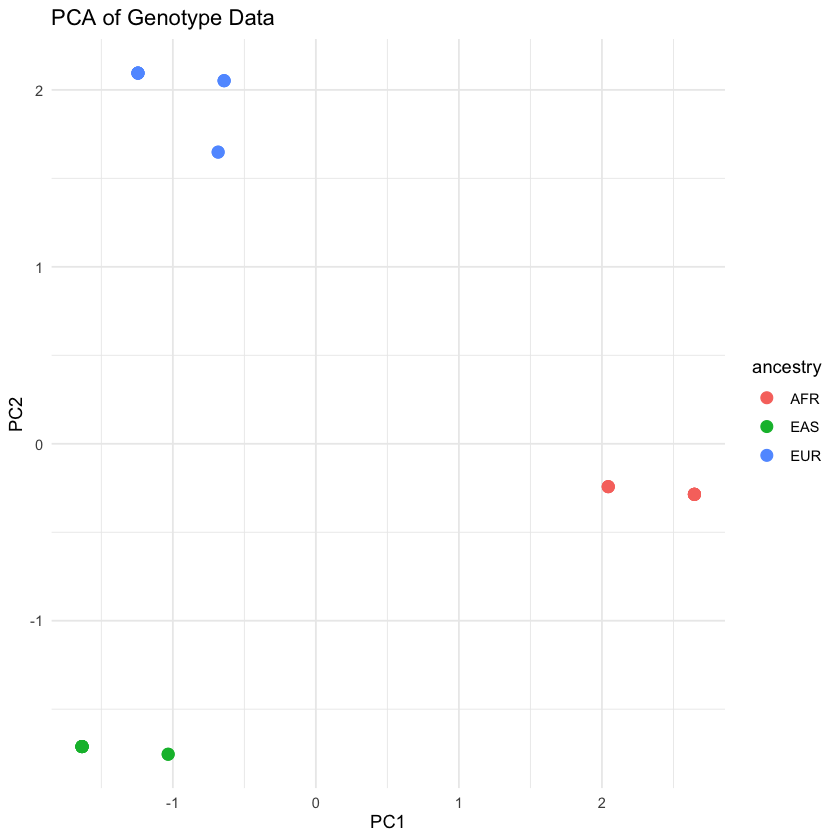

In [ ]:
#Conducting PCA Analysis on Genotype Matrix and compare between different ancestry groups

#Import necessary libraries
library(ggplot2)
library(stats) #for prcomp function
library(dplyr)

#Join metadata and genotypes to ensure alignment 
df_combined <- df_genotypes_clean %>%
  inner_join(df_metadata_clean, by = "sample_id")

#Select only the numeric variant columns (rs1, rs2, etc.) for PCA
#We remove sample_id and any metadata columns
pca_input <- df_combined %>%
  select(starts_with("rs")) 

#Run PCA
#scale. = TRUE ensures all variants contribute equally since PCA requires standardized data

#prcomp function performs PCA, which is a statistical procedure that uses an orthogonal 
#transformation (independent components) to convert a set of observations of possibly correlated variables into a 
#set of values of linearly uncorrelated variables called principal components. 
pca_result <- prcomp(pca_input, center = TRUE, scale. = TRUE)

# View summary of importance (Variance explained)
print("PCA Summary:")
summary(pca_result)


# Create a dataframe of scores for plotting

#Extract the PCA scores (principal component values) into a dataframe to show the significant components
#and how they relate to the samples.
df_pca_scores <- as.data.frame(pca_result$x)   

# Add sample_id back to the PCA scores for merging with metadata
#Adding sample_id back is necessary to link PCA results with original samples for further analysis
df_pca_scores$sample_id <- df_combined$sample_id


# Merge PCA scores with metadata to get batch and ancestry information for plotting
# the batches represent different groups of samples that were processed together, which can introduce technical variation
df_pca_scores$batch <- df_combined$batch      
# Add ancestry information to the PCA scores dataframe for coloring in the plot
df_pca_scores$ancestry <- df_combined$ancestry 


#observe metadata with bringing back sample_id, batch, and ancestry to the PCA scores dataframe
print("PCA Scores with Metadata:")
head(df_pca_scores)


# Visualize 
ggplot(df_pca_scores, aes(x = PC1, y = PC2, color = ancestry)) +
  geom_point(size = 3) +
  labs(title = "PCA of Genotype Data", x = "PC1", y = "PC2") +
  theme_minimal()

### The PCA plot above visualizes the genetic relationships between the individuals in the dataset.

PC1 (Horizontal Axis): This represents the "direction" in the data that accounts for the most variation. In genetic studies, PC1 usually separates the most genetically distant groups (e.g., often separating African populations from non-African populations).

PC2 (Vertical Axis): This accounts for the second most variation. It separates the remaining groups that weren't separated by PC1 (e.g., separating European from East Asian).


#### The Distance

Closer together = More Genetically Similar: If two dots are right next to each other, those two individuals have very similar genotypes (they likely have the same values for rs1, rs2, etc.).

Farther apart = More Genetically Different: If the "AFR" cluster is far away from the "EUR" cluster, it means those two populations have very different allele frequencies for these specific variants.

[1] "Number of unique data points: 7"


Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


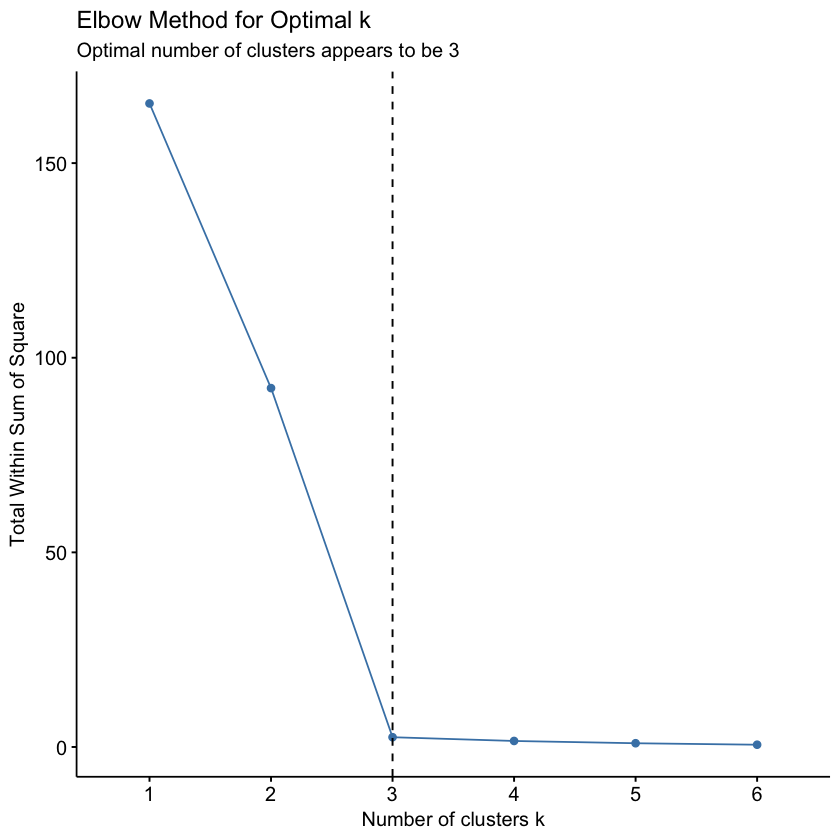

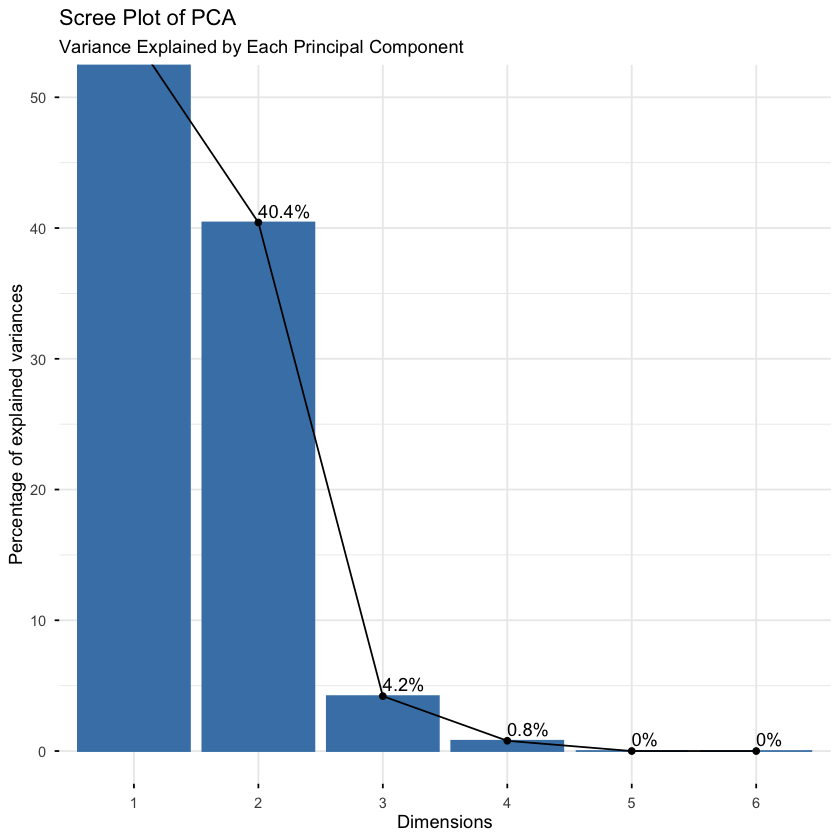

In [36]:
# Elbow Method - finding optimal number of clusters (k) for k-means clustering on PCA scores

library(factoextra)
# Check how many unique points you have (just for your info)
n_unique <- nrow(unique(df_pca_scores[, 1:2]))
print(paste("Number of unique data points:", n_unique))

# Run the Elbow Method with a safe k.max
set.seed(42) # For reproducibility

#fviz_nbclust is a function from the factoextra package that computes and visualizes the optimal number of clusters using different methods
#including the Elbow method which looks at the within-cluster sum of squares (WCSS) to determine the optimal k.
#We set k.max to be slightly less than n_unique, or just a small number like 10, to avoid errors if we have very few unique points.
fviz_nbclust(df_pca_scores[, 1:2], kmeans, method = "wss", k.max = min(10, n_unique - 1)) +
  geom_vline(xintercept = 3, linetype = 2) +
  labs(title = "Elbow Method for Optimal k", 
       subtitle = "Optimal number of clusters appears to be 3")


#Elbow plot through scree plot of PCA variance explained
#The scree plot shows the proportion of variance explained by each principal component, which can also help determine how many components to keep for downstream analysis.
fviz_eig(pca_result, addlabels = TRUE, ylim = c(0, 50)) +
  labs(title = "Scree Plot of PCA", 
       subtitle = "Variance Explained by Each Principal Component")

In small datasets with discrete values (0, 1, 2), it is very common for multiple individuals from the same ancestry group to have the exact same profile for the specific variants you are testing. In PCA space, these individuals land on the exact same dot, appearing as a single "distinct data point."

So we have to be careful when interpreting the PCA plot, as it may show distinct clusters that are actually just multiple samples with identical genotypes rather than true population structure. 

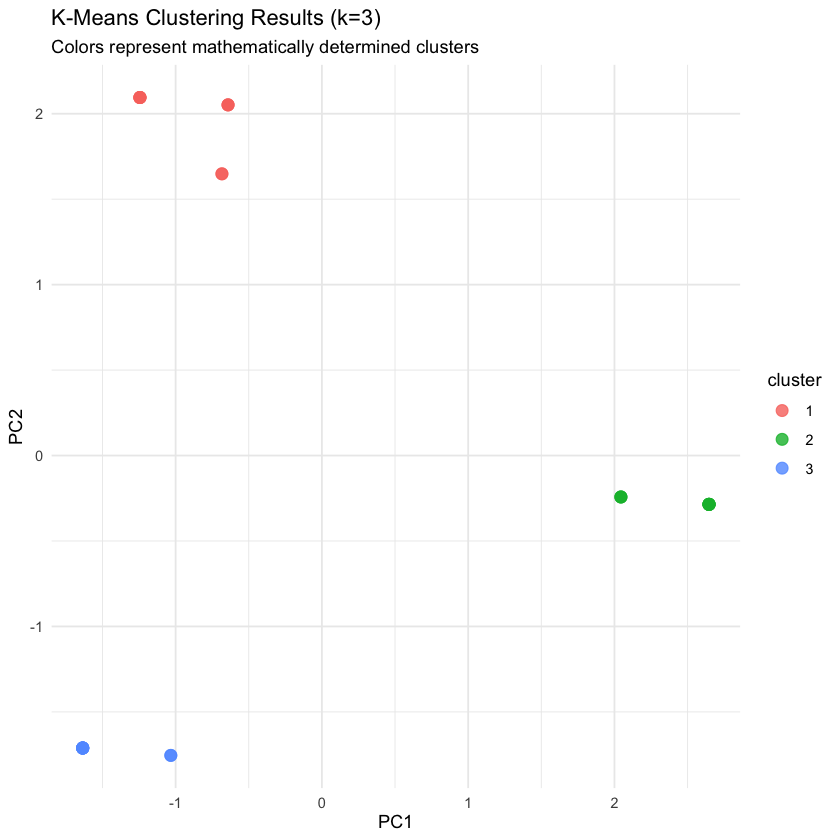

In [35]:
# Run K-Means with k=3
set.seed(42)
final_kmeans <- kmeans(df_pca_scores[, 1:2], centers = 3, nstart = 25)
df_pca_scores$cluster <- as.factor(final_kmeans$cluster)

# Plot 2: PCA colored by K-Means Cluster (Model Result)
ggplot(df_pca_scores, aes(x = PC1, y = PC2, color = cluster)) +
  geom_point(size = 3, alpha = 0.8) +
  labs(title = "K-Means Clustering Results (k=3)",
       subtitle = "Colors represent mathematically determined clusters",
       x = "PC1", y = "PC2") +
  theme_minimal()

This mathematically confirms that there are 3 distinct ancestral populations in your data.

If the elbow was at k=2, it would mean two of your groups (e.g., European and East Asian) were too similar to distinguish.

Since the elbow is at k=3, the math agrees with your labels: EUR, AFR, and EAS are three distinct groups.